In [3]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_table("wt_27ac_scores_per_100kb_new.tab",header=None)
df.columns = ["chr", "start", "end", "wt-k27ac_1", "wt-k27ac_2", "wt-input_1", "wt-input_2"]
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-input_1,wt-input_2
0,chr4,62413984,62414480,216.0,244.0,21.0,12.0
1,chr4,62454066,62455185,811.0,584.0,37.0,39.0
2,chr4,62460075,62460815,820.0,919.0,66.0,63.0
3,chr10,39860749,39861326,102.0,82.0,2.0,9.0
4,chr5,70616956,70617686,177.0,210.0,12.0,16.0


In [10]:
df = pd.read_table("pi_27ac_scores_per_100kb_new.tab",header=None)
df.columns = ["chr", "start", "end", "pi-k27ac_1", "pi-k27ac_2", "pi-input_1", "pi-input_2"]
df.head()

,chr,start,end,pi-k27ac_1,pi-k27ac_2,pi-input_1,pi-input_2
0,chr1,179690648,179691571,623.0,1041.0,38.0,42.0
1,chr4,13167198,13168502,342.0,474.0,16.0,13.0
2,chr2,49663129,49664062,133.0,190.0,2.0,8.0
3,chr2,49664309,49664967,144.0,255.0,8.0,6.0
4,chr10,68860133,68860683,99.0,143.0,6.0,4.0


In [11]:
#calibrate depth
#df["wt-k27ac_1nor"] = df["wt-k27ac_1"]/47
#df["wt-k27ac_2nor"] = df["wt-k27ac_2"]/53
#df["wt-igg_1nor"] = df["wt-input_1"]/10
#df["wt-igg_2nor"] = df["wt-input_2"]/10
df["pi-k27ac_1nor"] = df["pi-k27ac_1"]/38
df["pi-k27ac_2nor"] = df["pi-k27ac_2"]/59
df["pi-igg_1nor"] = df["pi-input_1"]/8
df["pi-igg_2nor"] = df["pi-input_2"]/9
df.head()

,chr,start,end,pi-k27ac_1,pi-k27ac_2,pi-input_1,pi-input_2,pi-k27ac_1nor,pi-k27ac_2nor,pi-igg_1nor,pi-igg_2nor
0,chr1,179690648,179691571,623.0,1041.0,38.0,42.0,16.394737,17.644068,4.75,4.666667
1,chr4,13167198,13168502,342.0,474.0,16.0,13.0,9.000000,8.033898,2.00,1.444444
2,chr2,49663129,49664062,133.0,190.0,2.0,8.0,3.500000,3.220339,0.25,0.888889
3,chr2,49664309,49664967,144.0,255.0,8.0,6.0,3.789474,4.322034,1.00,0.666667
4,chr10,68860133,68860683,99.0,143.0,6.0,4.0,2.605263,2.423729,0.75,0.444444


In [5]:
df['wt-k27ac_mean'] = df[['wt-k27ac_1nor', 'wt-k27ac_2nor']].mean(axis=1)
df['wt-igg_mean'] = df[['wt-igg_1nor', 'wt-igg_2nor']].mean(axis=1)

In [12]:
df['pi-k27ac_mean'] = df[['pi-k27ac_1nor', 'pi-k27ac_2nor']].mean(axis=1)
df['pi-igg_mean'] = df[['pi-igg_1nor', 'pi-igg_2nor']].mean(axis=1)

In [13]:
df.head()

,chr,start,end,pi-k27ac_1,pi-k27ac_2,pi-input_1,pi-input_2,pi-k27ac_1nor,pi-k27ac_2nor,pi-igg_1nor,pi-igg_2nor,pi-k27ac_mean,pi-igg_mean
0,chr1,179690648,179691571,623.0,1041.0,38.0,42.0,16.394737,17.644068,4.75,4.666667,17.019402,4.708333
1,chr4,13167198,13168502,342.0,474.0,16.0,13.0,9.000000,8.033898,2.00,1.444444,8.516949,1.722222
2,chr2,49663129,49664062,133.0,190.0,2.0,8.0,3.500000,3.220339,0.25,0.888889,3.360169,0.569444
3,chr2,49664309,49664967,144.0,255.0,8.0,6.0,3.789474,4.322034,1.00,0.666667,4.055754,0.833333
4,chr10,68860133,68860683,99.0,143.0,6.0,4.0,2.605263,2.423729,0.75,0.444444,2.514496,0.597222


In [14]:
#df["wt-k27ac_change"] = np.log2((df["wt-k27ac_mean"] + 1e-3)/(df["wt-igg_mean"] + 1e-3))
df["pi-k27ac_change"] = np.log2((df["pi-k27ac_mean"] + 1e-3)/(df["pi-igg_mean"] + 1e-3))
df.head()

,chr,start,end,pi-k27ac_1,pi-k27ac_2,pi-input_1,pi-input_2,pi-k27ac_1nor,pi-k27ac_2nor,pi-igg_1nor,pi-igg_2nor,pi-k27ac_mean,pi-igg_mean,pi-k27ac_change
0,chr1,179690648,179691571,623.0,1041.0,38.0,42.0,16.394737,17.644068,4.75,4.666667,17.019402,4.708333,1.853670
1,chr4,13167198,13168502,342.0,474.0,16.0,13.0,9.000000,8.033898,2.00,1.444444,8.516949,1.722222,2.305397
2,chr2,49663129,49664062,133.0,190.0,2.0,8.0,3.500000,3.220339,0.25,0.888889,3.360169,0.569444,2.558805
3,chr2,49664309,49664967,144.0,255.0,8.0,6.0,3.789474,4.322034,1.00,0.666667,4.055754,0.833333,2.281630
4,chr10,68860133,68860683,99.0,143.0,6.0,4.0,2.605263,2.423729,0.75,0.444444,2.514496,0.597222,2.072089


In [15]:
#df.loc[df['wt-k27ac_change'] < 0, 'wt-k27ac_change'] = 0
df.loc[df['pi-k27ac_change'] < 0, 'pi-k27ac_change'] = 0
df.head()

,chr,start,end,pi-k27ac_1,pi-k27ac_2,pi-input_1,pi-input_2,pi-k27ac_1nor,pi-k27ac_2nor,pi-igg_1nor,pi-igg_2nor,pi-k27ac_mean,pi-igg_mean,pi-k27ac_change
0,chr1,179690648,179691571,623.0,1041.0,38.0,42.0,16.394737,17.644068,4.75,4.666667,17.019402,4.708333,1.853670
1,chr4,13167198,13168502,342.0,474.0,16.0,13.0,9.000000,8.033898,2.00,1.444444,8.516949,1.722222,2.305397
2,chr2,49663129,49664062,133.0,190.0,2.0,8.0,3.500000,3.220339,0.25,0.888889,3.360169,0.569444,2.558805
3,chr2,49664309,49664967,144.0,255.0,8.0,6.0,3.789474,4.322034,1.00,0.666667,4.055754,0.833333,2.281630
4,chr10,68860133,68860683,99.0,143.0,6.0,4.0,2.605263,2.423729,0.75,0.444444,2.514496,0.597222,2.072089


In [9]:
h3k27ac = df[["chr","start","end","wt-k27ac_change"]] 
h3k27ac.head()
h3k27ac.to_csv("wt_h3k27ac_change.txt", sep="\t", index=False)

In [16]:
h3k27ac = df[["chr","start","end","pi-k27ac_change"]] 
h3k27ac.head()
h3k27ac.to_csv("pi_h3k27ac_change.txt", sep="\t", index=False)

In [1]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu, normaltest

In [7]:
h3k27ac = pd.read_table("enhancer_27ac.txt",header=None)
h3k27ac.columns = ["chr", "start", "end", "log2H3K27ac", "Group"]
h3k27ac.head()

,chr,start,end,log2H3K27ac,Group
0,chr4,62413984,62414480,1.478532,wt
1,chr4,62454066,62455185,1.895137,wt
2,chr4,62460075,62460815,1.431013,wt
3,chr10,39860749,39861326,1.754939,wt
4,chr5,70616956,70617686,1.464053,wt


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

wt vs. pi: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=7.364e+07


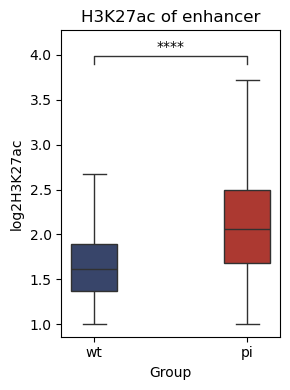

In [9]:
fig, ax = plt.subplots(figsize=(3,4))
ax = sns.boxplot(x='Group', y='log2H3K27ac', hue="Group", data=h3k27ac, showfliers=False,width=0.3,palette=("#304172", "#c0271d"))
pairs = [('wt','pi')]
annotator = Annotator(ax, pairs, x='Group', y='log2H3K27ac', hue="Group", data=h3k27ac, showfliers=False,width=0.3,palette=("#304172", "#c0271d"))
annotator.configure(test='Mann-Whitney', text_format='star',line_height=0.03, line_width=1)
annotator.apply_and_annotate()
plt.title("H3K27ac of enhancer")
plt.savefig("enhancer_27ac.pdf")
plt.tight_layout()
plt.show()